# Record and analyze

**What you'll learn / who it's for (simulation).** The recording API tour: tap spikes with a `spike_recorder` and analog signals with a `multimeter`, read the data back, and analyze it — firing rate, raster, spike times in two formats, and the inter-spike-interval (ISI) coefficient of variation.

Ported from `examples/nest_like/recording_demo.py`. Recording is **in memory** — there is no file backend yet — so NEST's `record_to` backend axis collapses to the in-memory equivalent.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import brainstate
brainstate.environ.set(precision=64)

import numpy as np
import brainunit as u
import matplotlib.pyplot as plt
from brainpy import state as bp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A trivial network to record from

A single `poisson_generator` drives one `iaf_psc_exp`. We attach two recorders: a `spike_recorder` for spikes and a `multimeter` recording `V_m` at the simulation resolution. The high (1 MHz) drive saturates the neuron so it fires every refractory period — a steady stream of spikes to analyze.

In [2]:
dt = 0.1
sim = bp.Simulator(dt=dt * u.ms)
neuron = sim.create(bp.iaf_psc_exp, 1)
pg = sim.create(bp.poisson_generator, 1, rate=1_000_000. * u.Hz, rng_seed=0)
sr = sim.create(bp.spike_recorder)
mm = sim.create(bp.multimeter, record_from=['V_m'], interval=dt * u.ms)

sim.connect(pg, neuron, weight=10. * u.pA, delay=1.0 * u.ms)
sim.connect(neuron, sr)             # spike tap
sim.connect(mm, neuron)             # reversed: the multimeter observes the neuron

res = sim.simulate(100. * u.ms)

## Spike statistics: rate and event count

`res.rate(sr)` is the mean firing rate (Hz) and `res.n_events(sr)` the total spike count.

In [3]:
print(f'firing rate: {res.rate(sr):.2f} spks/s')
print(f'n_events:    {res.n_events(sr)}')

firing rate: 450.00 spks/s
n_events:    45


## Spike times in two formats

NEST's `time_in_steps` axis is reproduced post-hoc: the recorded spikes are the per-step spike matrix, which we convert either to integer step indices or to times in ms.

In [4]:
spk = np.asarray(res.spikes(sr)).reshape(-1)     # (n_steps,) for one neuron
steps = np.nonzero(spk > 0)[0]
t_ms = np.asarray(u.get_mantissa(res.times / u.ms))
spike_times = t_ms[steps]
print('first 8 spike steps :', steps[:8])
print('first 8 spike times :', np.round(spike_times[:8], 1), 'ms')

first 8 spike steps : [ 22  45  68  90 112 134 156 178]
first 8 spike times : [ 2.2  4.5  6.8  9.  11.2 13.4 15.6 17.8] ms


## Analog recording and the ISI coefficient of variation

The `multimeter` trace is read with `res.trace(mm, 'V_m')`. From the spike times we compute the ISI CV (std/mean of inter-spike intervals) — a refractory-limited regular train has a small CV.

V_m trace: 1000 samples, min -70.00 mV, max -55.14 mV
ISI CV: 0.009  (mean ISI 2.20 ms)


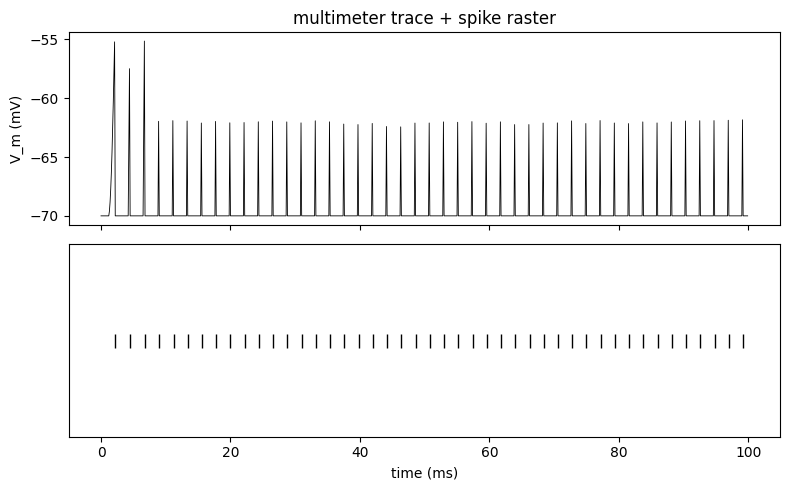

In [5]:
v = np.asarray(u.get_mantissa(res.trace(mm, 'V_m') / u.mV)).reshape(-1)
print(f'V_m trace: {v.shape[0]} samples, min {v.min():.2f} mV, max {v.max():.2f} mV')

isi = np.diff(spike_times)
if isi.size:
    cv = float(isi.std() / isi.mean())
    print(f'ISI CV: {cv:.3f}  (mean ISI {isi.mean():.2f} ms)')

fig, (a0, a1) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
a0.plot(t_ms, v, color='k', lw=0.6); a0.set_ylabel('V_m (mV)')
a1.plot(spike_times, np.ones_like(spike_times), 'k|', ms=10)
a1.set_xlabel('time (ms)'); a1.set_yticks([])
a0.set_title('multimeter trace + spike raster')
fig.tight_layout()

## See also

- [Devices](../devices.rst) — the full recorder / detector catalog.
- [Model anatomy](../../concepts/model-anatomy.ipynb) — how a neuron exposes its state and spikes.
- [Validation status](../validation-status.rst) — the spike-count and distributional parity categories.